In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter
from ipywidgets import interact, IntSlider

import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
import scipy.constants as const
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy import constants 
import os
import numpy as np
import pandas as pd
# from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from tqdm import tqdm  # Importing tqdm for progress bar
import matplotlib.ticker as ticker
import json
import pickle

textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/cooling_rates_ions/'

In [104]:
from ion_properties import lead,xenon,calcium

ions=[lead,xenon,calcium]


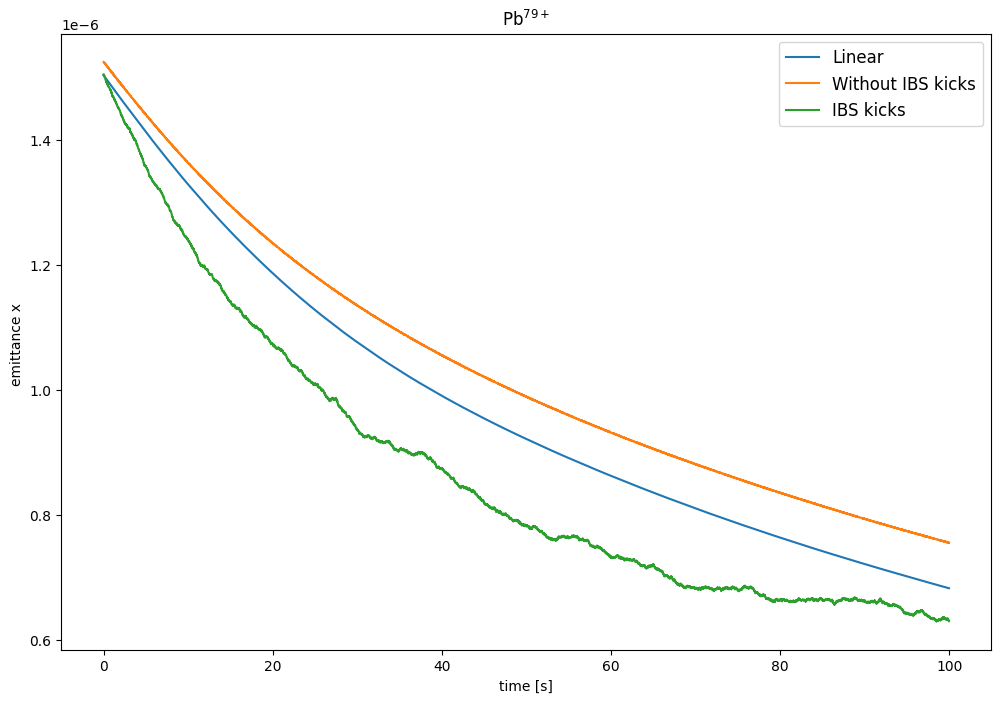

In [105]:
for ion in [lead]:

    loaded_data = np.load(f'../results/transverse/{ion.name}.npz')

    delta_linear = loaded_data['delta']
    zeta_linear = loaded_data['zeta']
    state_linear = loaded_data['state']
    x_linear = loaded_data['x']
    time_linear = loaded_data['time']
    s_per_turn_linear = loaded_data['s_per_turn']
    px_linear = loaded_data['px']
    action_x_linear = loaded_data['action_x']
    action_y_linear = loaded_data['action_y']
    emittance_x_linear = loaded_data['emittance_x']

    loaded_data_ibs = np.load(f'results/IBS/{ion.name}.npz')

    delta_ibs = loaded_data_ibs['delta']
    zeta_ibs = loaded_data_ibs['zeta']
    state_ibs = loaded_data_ibs['state']
    x_ibs = loaded_data_ibs['x']
    time_ibs = loaded_data_ibs['time']
    s_per_turn_ibs = loaded_data_ibs['s_per_turn']
    px_ibs = loaded_data_ibs['px']
    action_x_ibs = loaded_data_ibs['action_x']
    action_y_ibs = loaded_data_ibs['action_y']
    emittance_x_ibs = loaded_data_ibs['emittance_x']

    loaded_data = np.load(f'results/{ion.name}.npz')

    delta = loaded_data['delta']
    zeta = loaded_data['zeta']
    state = loaded_data['state']
    x = loaded_data['x']
    time=loaded_data['time']
    s_per_turn=loaded_data['s_per_turn']
    px=loaded_data['px']
    action_x=loaded_data['action_x']
    action_y=loaded_data['action_y']
    emittance_x=loaded_data['emittance_x']

    

    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 25})
    plt.title(f'{ion.name}')
    plt.plot(time_linear,emittance_x_linear,label='Linear')
    plt.plot(time,emittance_x,label='Without IBS kicks')
    plt.plot(time_ibs,emittance_x_ibs,label='IBS kicks')
    plt.xlabel('time [s]')
    plt.ylabel('emittance x ')
    ax = plt.gca()
    ax.yaxis.get_major_formatter().set_useOffset(False)
    # plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.legend()
    plt.show()

Transverse cooling for all ions

/tmp/pkruyt/ipykernel_57763/2562476341.py:26: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exponential_func, time, emittance_x)


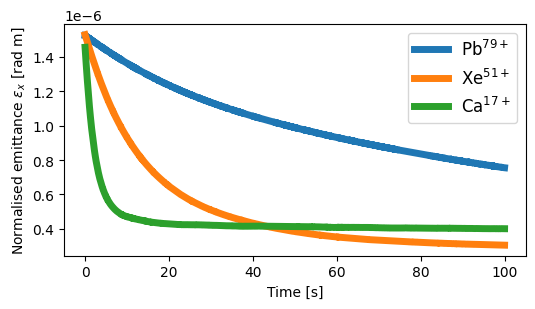

In [106]:
growth_rate_list=[]
ion_names=[ion.name for ion in ions]
ion_energy=[ion.hw0 for ion in ions]

fig=plt.figure()

for ion in ions:
    loaded_data = np.load(f'results/{ion.name}.npz')

    delta = loaded_data['delta']
    zeta = loaded_data['zeta']
    state = loaded_data['state']
    x = loaded_data['x']*1e3
    time=loaded_data['time']
    s_per_turn=loaded_data['s_per_turn']
    px=loaded_data['px']
    action_x=loaded_data['action_x']
    action_y=loaded_data['action_y']
    emittance_x=loaded_data['emittance_x']

     # Define the exponential function
    def exponential_func(x, a, b):
        return emittance_x[0] * np.exp(x * b)

    # Fit the data to the exponential function
    params, covariance = curve_fit(exponential_func, time, emittance_x)

    # Extract the parameters
    a, b = params
    growth_rate_list.append(b)

    plt.plot(time,emittance_x, label=f'{ion.name}', linewidth=5.0)
plt.xlabel(r'Time [s]')
plt.ylabel(r'Normalised emittance $\epsilon_x$ [rad m]')
plt.legend()
plt.tight_layout()
image_name = 'cooling_all_ions.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'cooling_all_ions.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
plt.show()

/tmp/pkruyt/ipykernel_57763/365310691.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exponential_func, time, emittance_x)


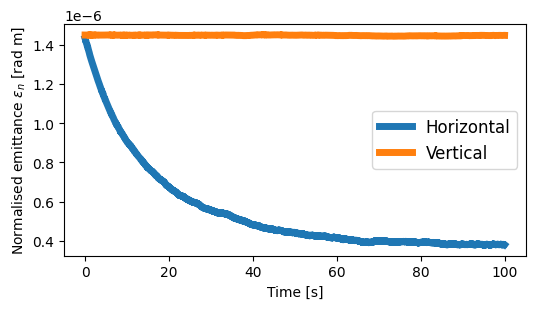

In [107]:
growth_rate_list=[]
ion_names=[ion.name for ion in ions]
ion_energy=[ion.hw0 for ion in ions]


fig=plt.figure()
#plt.rcParams.update({'font.size': 25})

for ion in [xenon]:
    loaded_data = np.load(f'results/IBS/{ion.name}.npz')

    delta = loaded_data['delta']
    zeta = loaded_data['zeta']
    state = loaded_data['state']
    x = loaded_data['x']*1e3
    time=loaded_data['time']
    s_per_turn=loaded_data['s_per_turn']
    px=loaded_data['px']
    action_x=loaded_data['action_x']
    action_y=loaded_data['action_y']
    emittance_x=loaded_data['emittance_x']
    emittance_y=np.mean(action_y,axis=1)*ion.gamma_cooling/2

     # Define the exponential function
    def exponential_func(x, a, b):
        return emittance_x[0] * np.exp(x * b)

    # Fit the data to the exponential function
    params, covariance = curve_fit(exponential_func, time, emittance_x)

    # Extract the parameters
    a, b = params
    growth_rate_list.append(b)

    plt.plot(time,emittance_x, label=f'Horizontal', linewidth=5.0)
    plt.plot(time,emittance_y, label=f'Vertical', linewidth=5.0)
plt.xlabel(r'Time [s]')
plt.ylabel(r'Normalised emittance $\epsilon_n$ [rad m]')
plt.legend()
plt.tight_layout()

# -----------------------------------------------------
# Save image and pickle the figure
# -----------------------------------------------------
# image_name = 'xenon_emittance_cooling.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')

# pickle_filename = 'xenon_emittance_cooling.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)


plt.show()

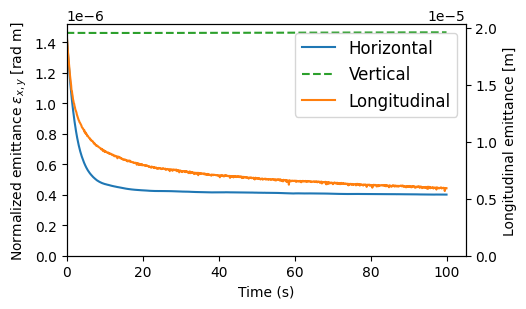

In [108]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax2 = ax1.twinx()

handles = []
labels = []

for ion_loop in [calcium]:
    loaded_data = np.load(f'results/{ion_loop.name}.npz')

    delta = loaded_data['delta']
    zeta = loaded_data['zeta']
    state = loaded_data['state']
    x = loaded_data['x'] 
    time = loaded_data['time']
    s_per_turn = loaded_data['s_per_turn']
    px = loaded_data['px']
    action_x = loaded_data['action_x']
    action_y = loaded_data['action_y']
    emittance_x = loaded_data['emittance_x']

    # If emittance_y not stored, estimate from action_y:
    try:
        emittance_y = loaded_data['emittance_y']
    except KeyError:
        emittance_y = np.mean(action_y, axis=1)*ion_loop.gamma_cooling/2  # Assuming normalized

    # Longitudinal emittance
    long_emittance = np.zeros(len(time))
    for i in range(len(time)):
        cov = np.cov(zeta[i, :], delta[i, :])
        long_emittance[i] = np.sqrt(np.linalg.det(cov))
    
    index = np.arange(0, len(time), 10)
    if index[-1] != len(time) - 1:
        index = np.append(index, len(time) - 1)

    # Horizontal emittance
    line1, = ax1.plot(time[index], emittance_x[index], linestyle='-', 
                      label='Horizontal emittance', color=cycle[0])
    handles.append(line1)
    labels.append('Horizontal')

    # Vertical emittance
    line2, = ax1.plot(time[index], emittance_y[index], linestyle='--',
                      label='Vertical', color=cycle[2])
    handles.append(line2)
    labels.append('Vertical')

    # Longitudinal emittance
    line3, = ax2.plot(time[index], long_emittance[index], label='Longitudinal', 
                      color=cycle[1])
    handles.append(line3)
    labels.append('Longitudinal')

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Normalized emittance $\\varepsilon_{x,y}$ [rad m]')
ax2.set_ylabel('Longitudinal emittance [m]')
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Force axes to start from 0
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)


plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
image_name = 'calcium_emittance_cooling.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'calcium_emittance_cooling.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()


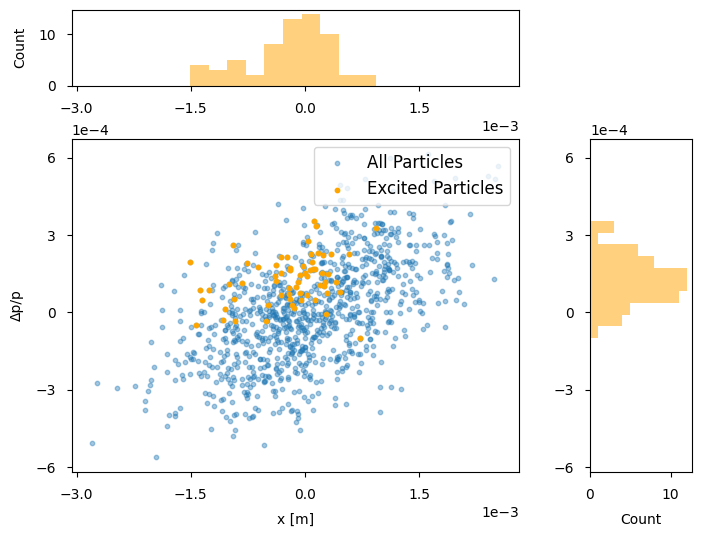

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import ScalarFormatter
import os
import pickle
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.ticker import MaxNLocator

ion_loop=xenon

# -----------------------------------------------------
# Example setup (assuming data is already loaded)
# -----------------------------------------------------
loaded_data = np.load(f'results/{ion_loop.name}.npz')

delta = loaded_data['delta']    # shape: (n_time, n_particles)
zeta = loaded_data['zeta']
state = loaded_data['state']
x = loaded_data['x'] 
time = loaded_data['time']
s_per_turn = loaded_data['s_per_turn']
px = loaded_data['px']
action_x = loaded_data['action_x']
action_y = loaded_data['action_y']
emittance_x = loaded_data['emittance_x']

turn = 0
excited_mask = (state[turn, :] == 2)

x_all = x[turn, :]
delta_all = delta[turn, :]

x_excited = x_all[excited_mask]
delta_excited = delta_all[excited_mask]


# Create figure with slightly relaxed spacing
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(4, 4, wspace=0.7, hspace=0.7)

# Define subplots
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# -----------------------------------------------------
# 1. Main scatter plot: show all particles and excited particles
# -----------------------------------------------------
# Multiply x by 1000 to convert to mm
ax_main.scatter(x_all, delta_all, s=10, alpha=0.4, label='All Particles')
# Plot excited particles on top in orange
ax_main.scatter(x_excited, delta_excited, s=10, color='orange', label='Excited Particles')
ax_main.set_xlabel('x [m]', labelpad=8)
ax_main.set_ylabel('Δp/p', labelpad=8)
ax_main.legend(loc='upper right')

# -----------------------------------------------------
# 2. Format axes: Using MaxNLocator and scientific notation
# -----------------------------------------------------
ax_main.xaxis.set_major_locator(MaxNLocator(5))
ax_main.yaxis.set_major_locator(MaxNLocator(5))
ax_top.xaxis.set_major_locator(MaxNLocator(5))
ax_right.yaxis.set_major_locator(MaxNLocator(5))

ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax_main.tick_params(axis='both', which='major', pad=8)
ax_top.tick_params(axis='both', which='major', pad=8)
ax_right.tick_params(axis='both', which='major', pad=8)

# -----------------------------------------------------
# 3. Top histogram: x distribution for excited particles only
# -----------------------------------------------------
bins_x = 10
ax_top.hist(x_excited, bins=bins_x, alpha=0.5, color='orange')
ax_top.set_ylabel('Count', labelpad=8)

# -----------------------------------------------------
# 4. Right histogram: Δp/p distribution for excited particles only
# -----------------------------------------------------
bins_delta = 10
ax_right.hist(delta_excited, bins=bins_delta, orientation='horizontal',
              alpha=0.5, color='orange')
ax_right.set_xlabel('Count', labelpad=8)


# # Save image
# image_name = 'excited_x_delta.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')

# # Save figure as pickle
# pickle_filename = 'excited_x_delta.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)

plt.show()


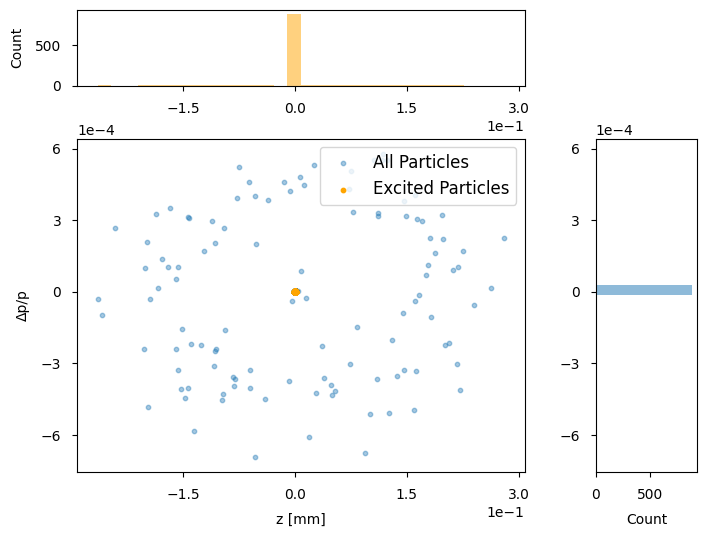

In [110]:
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.ticker import MaxNLocator

turn = -1
excited_mask = (state[turn, :] == 2)

x_all = zeta[turn, :]
delta_all = delta[turn, :]

x_excited = x_all[excited_mask]
delta_excited = delta_all[excited_mask]

# Create figure with slightly relaxed spacing
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(4, 4, wspace=0.7, hspace=0.7)

# Define subplots
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# -----------------------------------------------------
# 1. Main scatter plot: show all particles and excited particles
# -----------------------------------------------------
# Multiply x by 1000 to convert to mm
ax_main.scatter(x_all, delta_all, s=10, alpha=0.4, label='All Particles')
# Plot excited particles on top in orange
ax_main.scatter(x_excited, delta_excited, s=10, color='orange', label='Excited Particles')
ax_main.set_xlabel('z [mm]', labelpad=8)
ax_main.set_ylabel('Δp/p', labelpad=8)
ax_main.legend(loc='upper right')

# -----------------------------------------------------
# 2. Format axes: Using MaxNLocator and scientific notation
# -----------------------------------------------------
ax_main.xaxis.set_major_locator(MaxNLocator(5))
ax_main.yaxis.set_major_locator(MaxNLocator(5))
ax_top.xaxis.set_major_locator(MaxNLocator(5))
ax_right.yaxis.set_major_locator(MaxNLocator(5))

ax_main.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax_main.tick_params(axis='both', which='major', pad=8)
ax_top.tick_params(axis='both', which='major', pad=8)
ax_right.tick_params(axis='both', which='major', pad=8)

# -----------------------------------------------------
# 3. Top histogram: x distribution for excited particles only
# -----------------------------------------------------
bins_x = 30
ax_top.hist(x_all, bins=bins_x, alpha=0.5, color='orange')
ax_top.set_ylabel('Count', labelpad=8)

# -----------------------------------------------------
# 4. Right histogram: Δp/p distribution for excited particles only
# -----------------------------------------------------
bins_delta = 30
ax_right.hist(delta_all, bins=bins_delta, orientation='horizontal',
              alpha=0.5, color='C0')
ax_right.set_xlabel('Count', labelpad=8)

# -----------------------------------------------------
# Save image and pickle the figure
# -----------------------------------------------------
# image_name = 'excited_zeta_delta1.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')
# # Define your pickle filename
# pickle_filename = 'excited_zeta_delta1.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# # Save the figure object 'fig' using pickle
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)

plt.show()


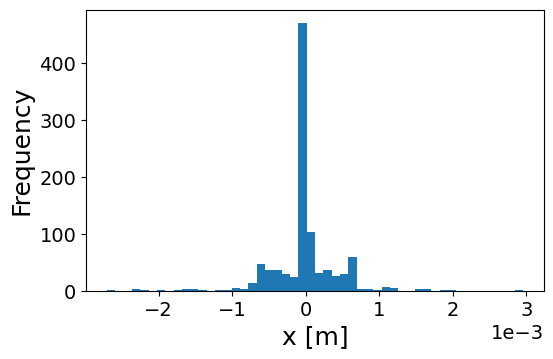

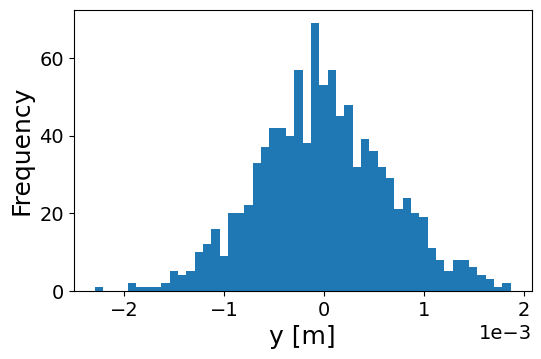

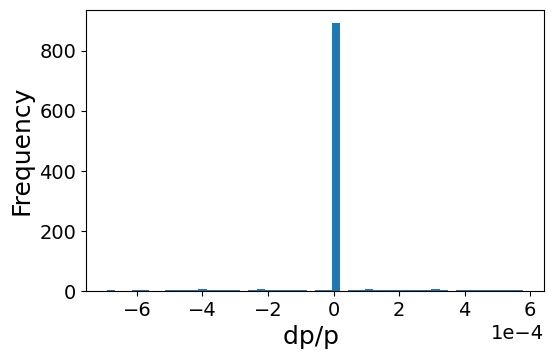

In [111]:
import matplotlib.pyplot as plt
import numpy as np

ion_loop=xenon

# -----------------------------------------------------
# Example setup (assuming data is already loaded)
# -----------------------------------------------------
loaded_data = np.load(f'results/{ion_loop.name}.npz')

delta = loaded_data['delta']    # shape: (n_time, n_particles)
zeta = loaded_data['zeta']
state = loaded_data['state']
x = loaded_data['x'] 
y = loaded_data['y'] 
time = loaded_data['time']
s_per_turn = loaded_data['s_per_turn']
px = loaded_data['px']
action_x = loaded_data['action_x']
action_y = loaded_data['action_y']
emittance_x = loaded_data['emittance_x']

# Increase font sizes globally
plt.rcParams.update({
    'font.size': 16,         # Base font size
    'axes.labelsize': 18,    # Axis labels
    'xtick.labelsize': 14,   # X tick labels
    'ytick.labelsize': 14,   # Y tick labels
    'legend.fontsize': 14,
    'figure.titlesize': 20
})


plt.figure()
plt.hist(x[-1], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('x [m]')
plt.ylabel('Frequency')
image_name = 'xenon_x_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'xenon_x_dist.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()

plt.figure()
plt.hist(y[-1], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('y [m]')
plt.ylabel('Frequency')
image_name = 'xenon_y_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'xenon_y_dist.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
plt.show()

plt.figure()
plt.hist(delta[-1], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('dp/p ')
plt.ylabel('Frequency')
image_name = 'xenon_delta_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'xenon_delta_dist.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
plt.show()


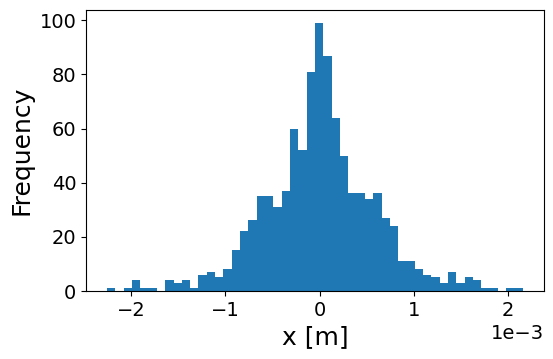

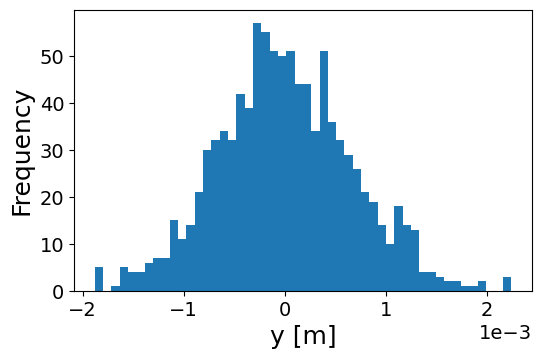

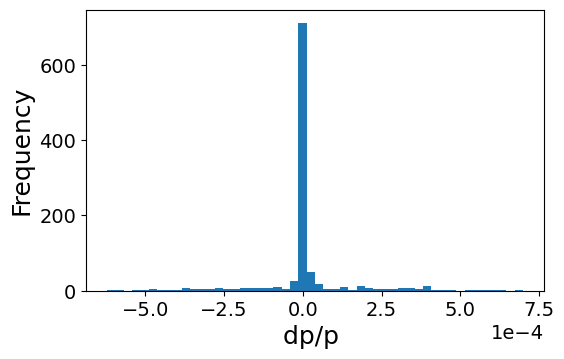

In [112]:
import matplotlib.pyplot as plt
import numpy as np

ion_loop=xenon

# -----------------------------------------------------
# Example setup (assuming data is already loaded)
# -----------------------------------------------------
loaded_data = np.load(f'results/{ion_loop.name}.npz')

delta = loaded_data['delta']    # shape: (n_time, n_particles)
zeta = loaded_data['zeta']
state = loaded_data['state']
x = loaded_data['x'] 
y = loaded_data['y'] 
time = loaded_data['time']
s_per_turn = loaded_data['s_per_turn']
px = loaded_data['px']
action_x = loaded_data['action_x']
action_y = loaded_data['action_y']
emittance_x = loaded_data['emittance_x']

target_time = 20.0
idx_closest = np.argmin(np.abs(time - target_time))

# Increase font sizes globally
plt.rcParams.update({
    'font.size': 16,         # Base font size
    'axes.labelsize': 18,    # Axis labels
    'xtick.labelsize': 14,   # X tick labels
    'ytick.labelsize': 14,   # Y tick labels
    'legend.fontsize': 14,
    'figure.titlesize': 20
})


plt.figure()
plt.hist(x[idx_closest], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('x [m]')
plt.ylabel('Frequency')
image_name = 'xenon_x_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

# pickle_filename = 'xenon_x_dist.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)

plt.show()

plt.figure()
plt.hist(y[idx_closest], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('y [m]')
plt.ylabel('Frequency')
image_name = 'xenon_y_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

# pickle_filename = 'xenon_y_dist.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)
plt.show()

plt.figure()
plt.hist(delta[idx_closest], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('dp/p ')
plt.ylabel('Frequency')
image_name = 'xenon_delta_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

# pickle_filename = 'xenon_delta_dist.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)
plt.show()


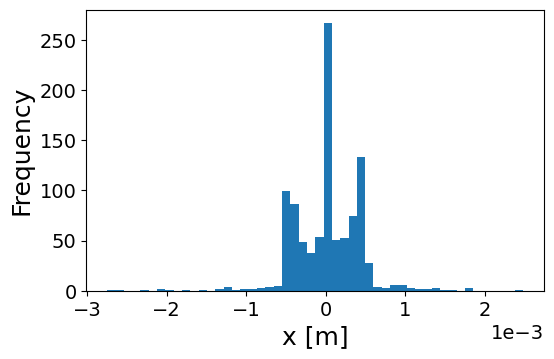

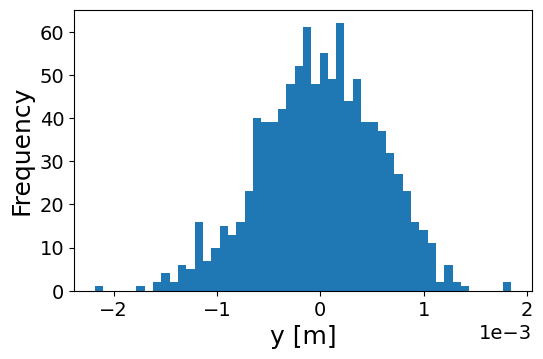

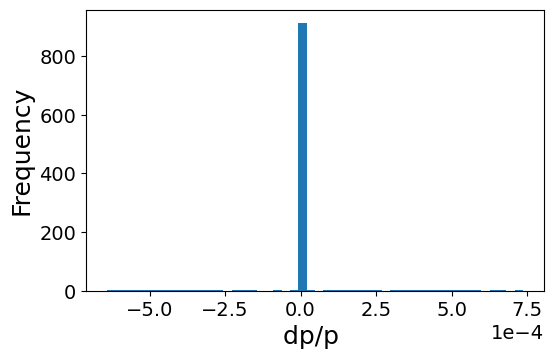

In [113]:
import matplotlib.pyplot as plt
import numpy as np

ion_loop=calcium

# -----------------------------------------------------
# Example setup (assuming data is already loaded)
# -----------------------------------------------------
loaded_data = np.load(f'results/{ion_loop.name}.npz')

delta = loaded_data['delta']    # shape: (n_time, n_particles)
zeta = loaded_data['zeta']
state = loaded_data['state']
x = loaded_data['x'] 
y = loaded_data['y'] 
time = loaded_data['time']
s_per_turn = loaded_data['s_per_turn']
px = loaded_data['px']
action_x = loaded_data['action_x']
action_y = loaded_data['action_y']
emittance_x = loaded_data['emittance_x']

# Increase font sizes globally
plt.rcParams.update({
    'font.size': 16,         # Base font size
    'axes.labelsize': 18,    # Axis labels
    'xtick.labelsize': 14,   # X tick labels
    'ytick.labelsize': 14,   # Y tick labels
    'legend.fontsize': 14,
    'figure.titlesize': 20
})


plt.figure()
plt.hist(x[-1], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('x [m]')
plt.ylabel('Frequency')
image_name = 'calcium_x_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'calcium_x_dist.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()

plt.figure()
plt.hist(y[-1], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('y [m]')
plt.ylabel('Frequency')
image_name = 'calcium_y_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'calcium_y_dist.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
plt.show()

plt.figure()
plt.hist(delta[-1], bins=50)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('dp/p ')
plt.ylabel('Frequency')
image_name = 'calcium_delta_dist.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

pickle_filename = 'calcium_delta_dist.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
plt.show()
